# EDA on Telco Churn Dataset
# =====================

# Load Dataset
# =====================

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("C:/New folder/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# -----------------------------
#  Basic Information
# -----------------------------

In [36]:
print("Dataset Shape:", df.shape)   # Rows & Columns
print("\nData Types:")
print(df.info())                    # Column types & nulls

Dataset Shape: (7043, 22)

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

# First 5 Rows info:

In [34]:
print("\nFirst 5 Rows:")
print(df.head())                    # Sample data


First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... TechSupport  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...         Yes   
4                No     Fiber optic             No  ...          No   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          

# Check missing values

In [35]:
# Check missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_numeric       0
dtype: int64


#  =====================
#  1. Churn Distribution
# =====================

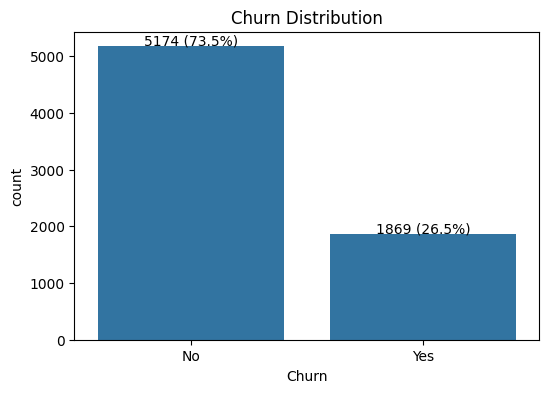

In [41]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)  # Removed palette
plt.title('Churn Distribution')

# Show percentages on top of bars
total = sum(churn_counts.values)
for i, value in enumerate(churn_counts.values):
    plt.text(i, value + 20, f'{value} ({value/total*100:.1f}%)', ha='center')
    
plt.show()

# ==================================
# 2. Monthly Charges vs Churn Status
# ==================================

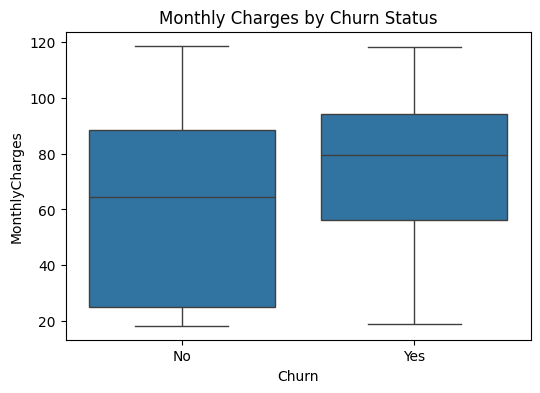

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')


    
plt.show()


# ==========================
# 3. Tenure Distribution
# ==========================

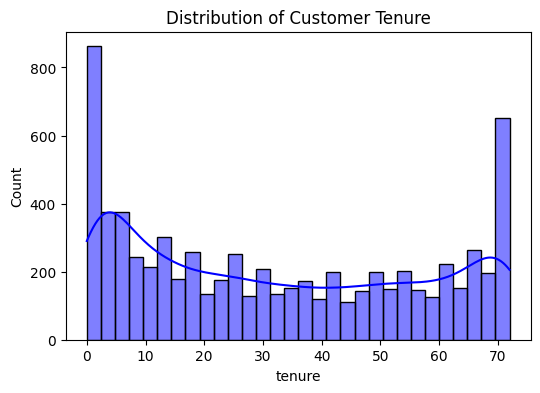

In [43]:
plt.figure(figsize=(6,4))
sns.histplot(df['tenure'], bins=30, kde=True, color='blue')
plt.title('Distribution of Customer Tenure')
plt.show()

==========================
4. Distribution of Payment Methods (Pie Chart)
==========================

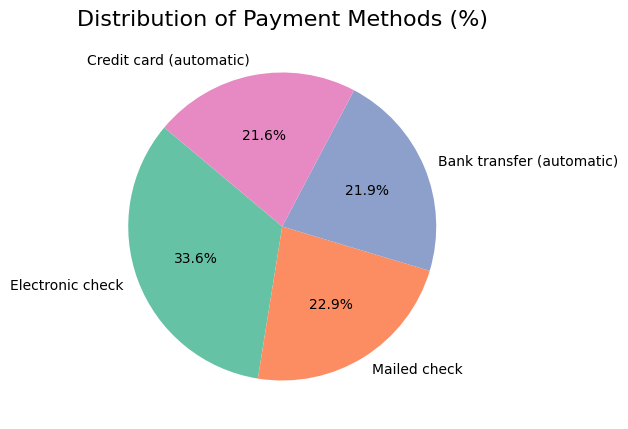

In [24]:
# 1. Distribution of Payment Methods (Pie Chart)
payment_perc = df["PaymentMethod"].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(payment_perc, labels=payment_perc.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set2.colors)
plt.title("Distribution of Payment Methods (%)", fontsize=16)
plt.show()

# Churn Rate by Payment Method (Pie Chart)

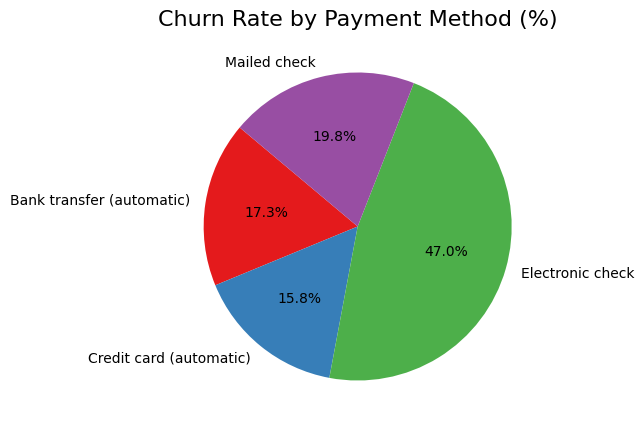

In [30]:
# Convert 'Churn' column to numeric: Yes=1, No=0
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Churn Rate by Payment Method (Pie Chart)
churn_perc = df.groupby("PaymentMethod")["Churn_numeric"].mean() * 100

plt.figure(figsize=(5,5))
plt.pie(churn_perc, labels=churn_perc.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set1.colors)
plt.title("Churn Rate by Payment Method (%)", fontsize=16)
plt.show()


# ==================================
# 5. Churn Rate by Contract Type
# ==================================

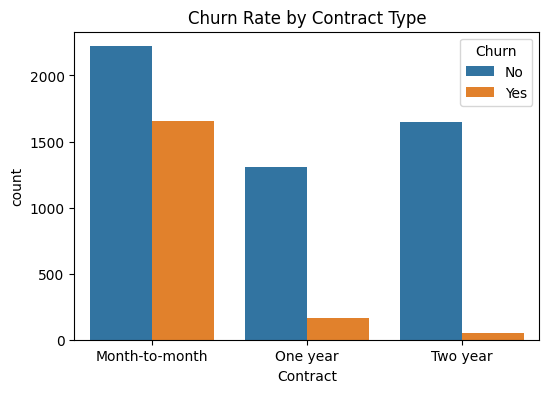

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)  
plt.title('Churn Rate by Contract Type')
plt.show()

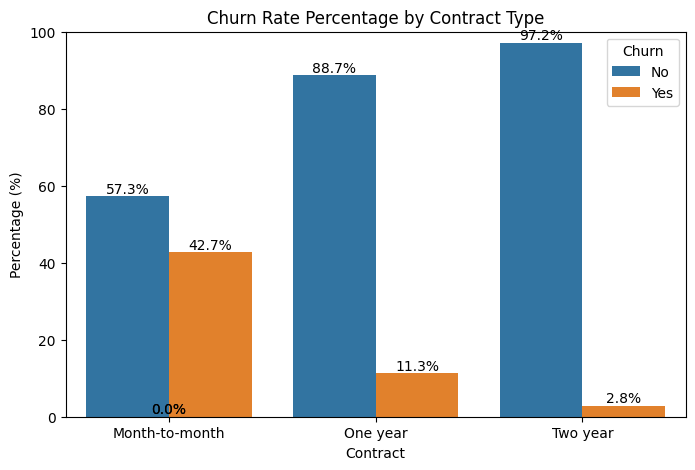

In [44]:
contract_churn = (
    df.groupby(['Contract', 'Churn'])
    .size()
    .reset_index(name='count')
)
# Calculate total customers per contract
total_per_contract = contract_churn.groupby('Contract')['count'].transform('sum')

# Calculate percent churn per contract type & churn class
contract_churn['percent'] = contract_churn['count'] / total_per_contract * 100
plt.figure(figsize=(8,5))
sns.barplot(x='Contract', y='percent', hue='Churn', data=contract_churn)

plt.ylabel('Percentage (%)')
plt.title('Churn Rate Percentage by Contract Type')
plt.ylim(0, 100)

# Annotate percentages on bars
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height:.1f}%', 
                       (p.get_x() + p.get_width() / 2, height), 
                       ha='center', va='bottom')
plt.show()

# ==================================
# 6. Correlation Heatmap
# ==================================

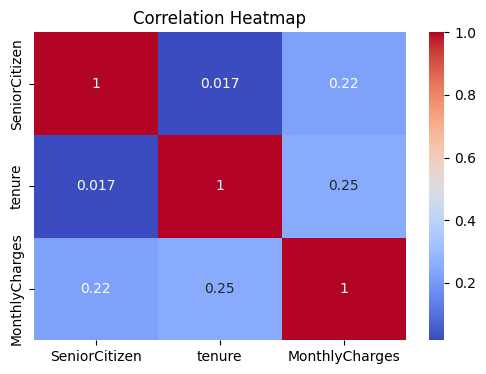

In [46]:
plt.figure(figsize=(6,4))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Clean data

In [47]:

if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
    
df.replace(['No internet service', 'No phone service'], 'No', inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df = pd.get_dummies(df, drop_first=True)

# Logistic Regression

Confusion Matrix:
[[749 286]
 [ 80 294]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC AUC Score: 0.8414


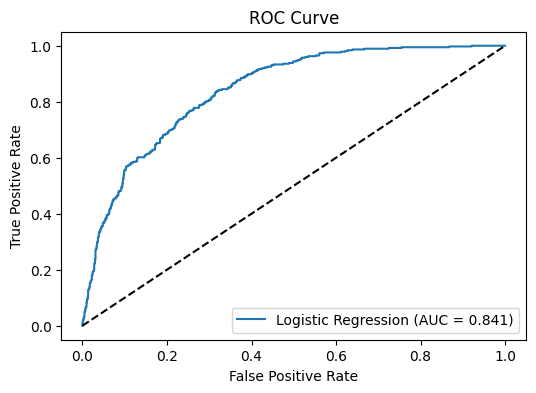

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split data into train and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize Logistic Regression model
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=42,class_weight='balanced'))

# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC

# Evaluation metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# hyperparameter tuning with GridSearchCV

Best Hyperparameters: {'lr__C': 1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}

Confusion Matrix:
[[663 372]
 [ 50 324]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76      1035
           1       0.47      0.87      0.61       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.70      0.72      1409

ROC AUC Score: 0.8414


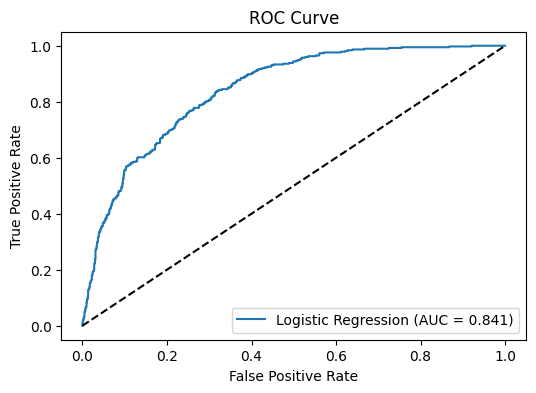

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced'))
])

# Define hyperparameter grid
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],       # Regularization strength
    'lr__penalty': ['l2'],                  # You can add 'l1' if using solver='liblinear'
    'lr__solver': ['lbfgs']                 # 'liblinear' works with l1 penalty
}

# GridSearchCV for hyperparameter tuning, optimizing for recall
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    scoring='recall',   # Focus on minimizing false negatives
    cv=5, 
    n_jobs=-1
)

# Train model with hyperparameter tuning
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Predict on test set
y_pred = grid_search.predict(X_test)
y_pred_prob = grid_search.predict_proba(X_test)[:, 1]

threshold = 0.4  # Adjust between 0.3 - 0.5 based on validation
y_pred = (y_pred_prob >= threshold).astype(int)

# Evaluation metrics
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


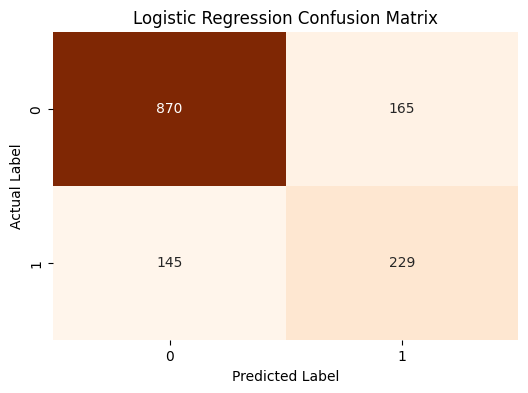

In [51]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


# Random Forest

Confusion Matrix:
[[933 102]
 [188 186]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC AUC Score: 0.8269


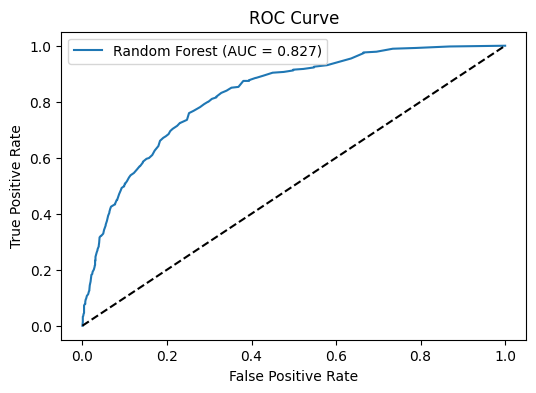

In [4]:
from sklearn.ensemble import RandomForestClassifier


# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,  # number of trees
    random_state=42,
    class_weight='balanced'  # helps with class imbalance
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# hyperparameter tuning with RandomizedSearchCV

Before SMOTE: [4139 1495]
After SMOTE: [4139 4139]
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 40, 'bootstrap': False}
Confusion Matrix:
[[865 170]
 [149 225]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.57      0.60      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.78      1409

ROC AUC Score: 0.8251


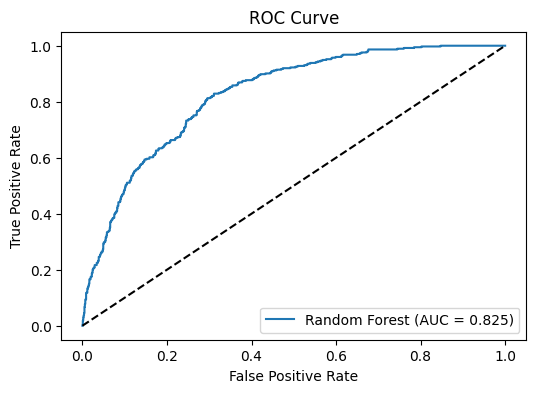

In [5]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import numpy as np

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split train/test data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {np.bincount(y_train)}")
print(f"After SMOTE: {np.bincount(y_train_sm)}")

# Define Random Forest and parameter grid for Randomized Search
rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Randomized Search CV
random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist,
    n_iter=20, cv=3, verbose=2, n_jobs=-1,
    scoring='roc_auc', random_state=42
)

# Train with tuned params on SMOTE data
random_search.fit(X_train_sm, y_train_sm)

print(f"Best parameters: {random_search.best_params_}")

# Best estimator
best_rf = random_search.best_estimator_

# Predict on test data
y_pred = best_rf.predict(X_test)
y_pred_prob = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


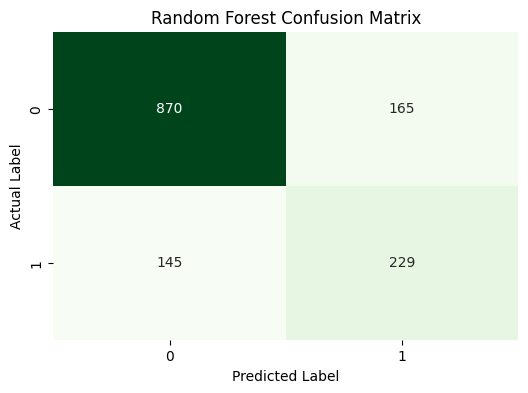

In [50]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Random Forest Confusion Matrix')
plt.show()


# Support Vector Machine (SVM)

Before SMOTE: [4139 1495]
After SMOTE: [4139 4139]
SVM Confusion Matrix:
[[848 187]
 [132 242]]

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.56      0.65      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.79      0.77      0.78      1409

SVM ROC AUC Score: 0.8073


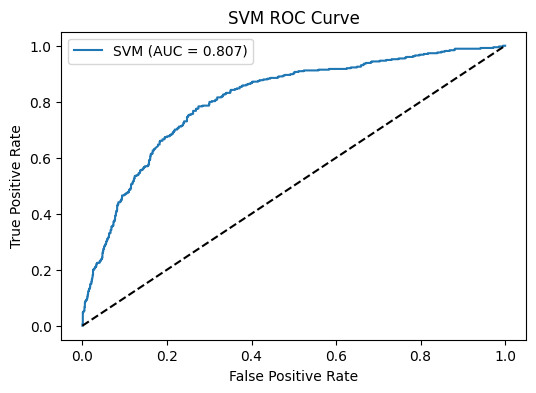

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import numpy as np

# Assume df is preprocessed with target 'Churn' mapped to 0/1

# 1. Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Split train/test with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {np.bincount(y_train)}")
print(f"After SMOTE: {np.bincount(y_train_sm)}")

# 4. Scale features (important for SVM)
scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize and train SVM with probability=True for ROC AUC
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

svm_model.fit(X_train_sm_scaled, y_train_sm)

# 6. Predictions
y_pred = svm_model.predict(X_test_scaled)
y_pred_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

# 7. Evaluation
print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"SVM ROC AUC Score: {roc_auc:.4f}")

# 8. Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()


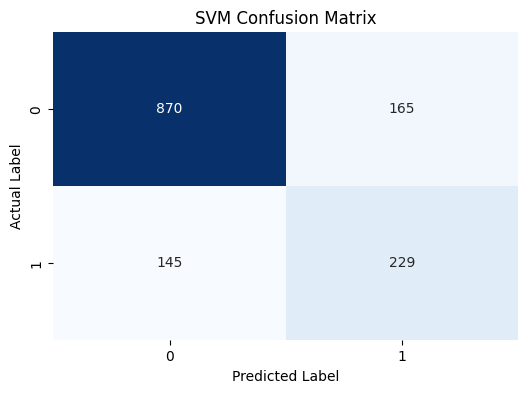

In [49]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('SVM Confusion Matrix')
plt.show()
